# Hybrid multimodal RAG — real Medium articles + Claude

**Meeting 14 — AI Engineering Course (BGU)**

We extend the OCR-first RAG from Meeting 13 into a **hybrid pipeline** over
**real Medium articles on data visualization**. The corpus has two indices:

- a **text index** built from article paragraphs (sentence-transformers)
- an **image index** built from article figures and charts (open-clip ViT-B/32)

At query time both are searched and merged with **Reciprocal Rank Fusion**.
The final answer is generated by **Claude multimodal**, which sees both the
retrieved text chunks **and** the retrieved figures.

What you'll see by the end of the notebook:

1. Live fetch + cache of Medium articles tagged `data-visualization`
2. Figure-level image embeddings with open-clip
3. A side-by-side comparison of three retrievers — **text only**, **image only**, **hybrid (RRF)**
4. A multimodal answer step (Claude) with a deterministic fallback when no API key is set
5. Queries that **only hybrid** can answer well (e.g. "show me a bar chart of …")

## 0 — Setup

Same `llm` conda env as M13, plus `feedparser` and `beautifulsoup4`. If
you're starting from a fresh env:

```bash
pip install requests beautifulsoup4 feedparser sentence-transformers \
            open_clip_torch faiss-cpu anthropic Pillow numpy
```

The notebook caches every Medium article and image under `artifacts_m14/`,
so re-runs are fully offline once the first run completes.

In [2]:
import os, io, re, json, base64, hashlib, textwrap
from pathlib import Path

import numpy as np
import requests
# import feedparser
from bs4 import BeautifulSoup
from PIL import Image

ARTIFACTS  = Path("artifacts_m14"); ARTIFACTS.mkdir(exist_ok=True)
HTML_CACHE = ARTIFACTS / "html";     HTML_CACHE.mkdir(exist_ok=True)
IMG_CACHE  = ARTIFACTS / "img";      IMG_CACHE.mkdir(exist_ok=True)
MD_DIR     = ARTIFACTS / "articles"; MD_DIR.mkdir(exist_ok=True)
META_FILE  = ARTIFACTS / "articles.json"

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 "
        "(KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    )
}
# Medium's CDN sometimes wants a Referer for image hot-linking.
IMG_HEADERS = {**HEADERS, "Referer": "https://medium.com/"}

print("artifacts:", ARTIFACTS.resolve())

artifacts: /media/amir/Windows-SSD/Users/User/Documents/bgu-ai/code/ai-rag-agents-course/meeting13-14/artifacts_m14


## 1 — Fetch real Medium articles

We pull the `data-visualization` RSS feed from Medium, then scrape each
article's HTML for paragraphs and embedded figures. Two things worth
flagging:

- Medium's real article figures live inside `<picture><source srcset="…">`
  — the bare `<img>` tag is usually just an author avatar. We parse the
  `srcset` and pick the highest-width URL.
- The CDN occasionally returns 403 unless the request carries a
  `Referer: https://medium.com/` header, so the image fetcher sets one.

Everything is cached under `artifacts_m14/`:

- `html/` — raw article HTML
- `img/`  — downloaded figures (named by URL hash)
- `articles/` — each article rewritten as a clean `.md` file with image
  references, suitable for re-reading or feeding into another pipeline
- `articles.json` — index of fetched articles

Once the first run completes, the notebook is fully reproducible offline.

In [3]:
def _sha(s: str) -> str:
    return hashlib.sha1(s.encode()).hexdigest()[:16]

def _is_avatar(url: str) -> bool:
    return any(x in url for x in (
        "resize:fill:", "resize:fit:48", "resize:fit:64",
        "resize:fit:88", "resize:fit:96",
    ))

def _img_ext(url: str) -> str:
    m = re.search(r"format:(webp|jpe?g|png|gif)/", url, re.I)
    if m:
        e = m.group(1).lower(); return ".jpg" if e == "jpeg" else f".{e}"
    m = re.search(r"\.(webp|jpe?g|png|gif)(?:$|\?)", url, re.I)
    if m:
        e = m.group(1).lower(); return ".jpg" if e == "jpeg" else f".{e}"
    return ".jpg"

def _best_from_srcset(srcset: str) -> str | None:
    """Parse 'url1 640w, url2 1080w' and return the highest-width URL."""
    best, best_w = None, -1
    for part in (srcset or "").split(","):
        bits = part.strip().split()
        if not bits: continue
        url, w = bits[0], 0
        if len(bits) > 1 and bits[1].endswith("w"):
            try: w = int(bits[1][:-1])
            except ValueError: pass
        if w > best_w:
            best, best_w = url, w
    return best

def cached_get(url: str, cache_dir: Path, ext: str = ".bin",
               headers: dict | None = None) -> Path:
    f = cache_dir / (_sha(url) + ext)
    if f.exists() and f.stat().st_size > 0:
        return f
    r = requests.get(url, headers=headers or HEADERS, timeout=20)
    r.raise_for_status()
    f.write_bytes(r.content)
    return f

def extract_article(html_bytes: bytes, url: str) -> dict:
    soup = BeautifulSoup(html_bytes, "html.parser")
    h1 = soup.find("h1")
    title = h1.get_text(strip=True) if h1 else url
    article = soup.find("article") or soup

    paragraphs = [
        p.get_text(" ", strip=True)
        for p in article.find_all("p")
        if len(p.get_text(strip=True)) > 60
    ]

    # Real figures live inside <picture><source srcset="..."> — the bare
    # <img> on Medium is usually just an author avatar.
    images = []
    for pic in article.find_all("picture"):
        for s in pic.find_all("source"):
            srcset = s.get("srcset") or s.get("data-srcset")
            cand = _best_from_srcset(srcset)
            if cand and cand.startswith("http") and not _is_avatar(cand):
                images.append(cand); break  # one per <picture>

    # Fallback: bare <img> with src/data-src/srcset
    if len(images) < 2:
        for img in article.find_all("img"):
            cand = (
                img.get("src")
                or img.get("data-src")
                or _best_from_srcset(img.get("srcset") or img.get("data-srcset") or "")
            )
            if not cand or not cand.startswith("http"): continue
            if "miro.medium" not in cand and "cdn-images-1.medium" not in cand: continue
            if _is_avatar(cand): continue
            images.append(cand)

    seen, uniq = set(), []
    for s in images:
        if s in seen: continue
        seen.add(s); uniq.append(s)
    return {"url": url, "title": title, "paragraphs": paragraphs, "images": uniq[:6]}

def _slug(title: str) -> str:
    s = re.sub(r"[^a-zA-Z0-9]+", "-", title.lower()).strip("-")
    return s[:60] or "article"

def write_markdown(article: dict, md_dir: Path) -> Path:
    """Save the article as Markdown with image references."""
    path = md_dir / f"{_slug(article['title'])}.md"
    lines = [
        "---",
        f"title: {json.dumps(article['title'])}",
        f"url: {article['url']}",
        f"images: {len(article.get('local_images', []))}",
        "---",
        "",
        f"# {article['title']}",
        "",
        f"_Source: <{article['url']}>_",
        "",
    ]
    imgs = list(article.get("local_images", []))
    for i, p in enumerate(article["paragraphs"]):
        lines += [p, ""]
        # interleave a figure every ~3 paragraphs while we still have any
        if imgs and i % 3 == 2:
            rel = os.path.relpath(imgs.pop(0), md_dir)
            lines += [f"![figure]({rel})", ""]
    for img in imgs:
        rel = os.path.relpath(img, md_dir)
        lines += [f"![figure]({rel})", ""]
    path.write_text("\n".join(lines), encoding="utf-8")
    return path

def fetch_articles(tag: str = "data-visualization",
                   target: int = 3, max_try: int = 12,
                   min_pars: int = 6, min_imgs: int = 2) -> list[dict]:
    if META_FILE.exists():
        cached = json.loads(META_FILE.read_text())
        if len(cached) >= target:
            print(f"[cache] reusing {len(cached)} article(s) from {META_FILE.name}")
            return cached
    feed = feedparser.parse(f"https://medium.com/feed/tag/{tag}")
    print(f"RSS entries: {len(feed.entries)}")
    out = []
    for entry in feed.entries[:max_try]:
        try:
            html_path = cached_get(entry.link, HTML_CACHE, ".html")
            art = extract_article(html_path.read_bytes(), entry.link)
        except Exception as e:
            print(f"  skip {entry.link[:60]}: {type(e).__name__}: {e}")
            continue
        if len(art["paragraphs"]) < min_pars or len(art["images"]) < min_imgs:
            print(f"  thin  {art['title'][:60]} "
                  f"(p={len(art['paragraphs'])}, i={len(art['images'])})")
            continue
        local = []
        for img_url in art["images"]:
            try:
                p = cached_get(img_url, IMG_CACHE,
                               ext=_img_ext(img_url), headers=IMG_HEADERS)
                local.append(str(p))
            except Exception as e:
                print(f"    img skip ({type(e).__name__}): {img_url[:60]}")
        art["local_images"] = local
        md_path = write_markdown(art, MD_DIR)
        art["markdown"] = str(md_path)
        out.append(art)
        print(f"  keep  {art['title'][:60]} "
              f"(p={len(art['paragraphs'])}, i={len(local)}, md={md_path.name})")
        if len(out) >= target:
            break
    META_FILE.write_text(json.dumps(out, indent=2))
    return out

In [4]:
articles = fetch_articles()
print(f"\nFetched {len(articles)} article(s)")
for a in articles:
    print(f"  - {a['title'][:80]}  [{len(a['local_images'])} imgs]")

NameError: name 'feedparser' is not defined

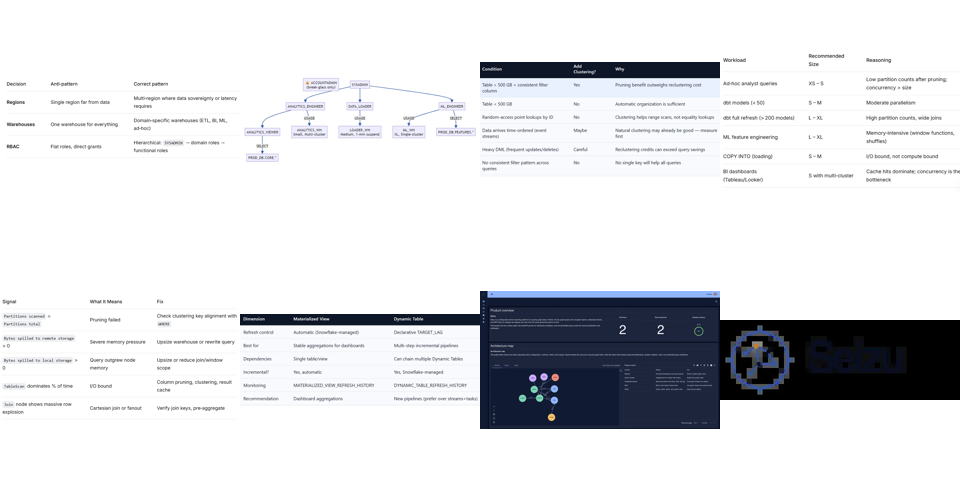

In [9]:
# Visual check — collage of the first few fetched figures
from PIL import Image as PILImage

THUMB = 240
def collage(paths, cols=4):
    paths = paths[:8]
    if not paths:
        return None
    rows = (len(paths) + cols - 1) // cols
    grid = PILImage.new("RGB", (THUMB*cols, THUMB*rows), "white")
    for i, p in enumerate(paths):
        try:
            im = PILImage.open(p).convert("RGB")
        except Exception:
            continue
        im.thumbnail((THUMB, THUMB))
        x = (i % cols) * THUMB; y = (i // cols) * THUMB
        grid.paste(im, (x + (THUMB - im.width)//2,
                        y + (THUMB - im.height)//2))
    return grid

all_imgs = [p for a in articles for p in a["local_images"]]
collage(all_imgs)

## 2 — Text index over the articles

No OCR this time — Medium hands us clean HTML. We chunk each article into
roughly 400-character blocks and embed with the same multilingual
sentence-transformer used in M13, so the embedding code is identical to a
plain text RAG.

Each record carries `(article_idx, modality='text')` metadata so we can
trace a retrieval hit back to its source article.

In [10]:
def chunk_paragraphs(paragraphs: list[str], target: int = 400) -> list[str]:
    chunks, buf = [], ""
    for p in paragraphs:
        if len(buf) + len(p) + 2 > target and buf:
            chunks.append(buf.strip())
            buf = p
        else:
            buf = (buf + "\n\n" + p).strip() if buf else p
    if buf:
        chunks.append(buf.strip())
    return chunks

In [11]:
text_records = []
for idx, art in enumerate(articles):
    for ch in chunk_paragraphs(art["paragraphs"]):
        text_records.append({
            "text": ch,
            "article_idx": idx,
            "title": art["title"],
            "modality": "text",
        })

print(f"text records: {len(text_records)}")
for r in text_records[:6]:
    print(f"  [a{r['article_idx']}] {r['text'][:80]}…")

text records: 65
  [a0] Three years into my Snowflake career, I watched a single overnight job burn $4,0…
  [a0] Six years later, I inherited a $140K monthly bill. Three months after that, it w…
  [a0] This article is everything I learned across six years. The architecture. The opt…
  [a0] If you’re earlier in your Snowflake journey, consider this a map. If you’re a fe…
  [a0] This separation is the core insight, formalised in Dageville et al. (2016), The …
  [a0] What it means in practice: ten teams can query the same underlying data simultan…


In [12]:
from sentence_transformers import SentenceTransformer

text_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
text_emb   = text_model.encode(
    [r["text"] for r in text_records],
    normalize_embeddings=True,
    show_progress_bar=False,
)
print("text embeddings shape:", text_emb.shape)

/home/amir/miniconda3/envs/llm/lib/python3.12/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange
/home/amir/miniconda3/envs/llm/lib/python3.12/site-packages/sentence_transformers/model_card.py:515: SyntaxWarning: invalid escape sequence '\d'
  if dataset_name and re.match("_dataset_\d+", dataset_name):


ModuleNotFoundError: Could not import module 'CodeCarbonCallback'. Are this object's requirements defined correctly?

## 3 — Image index with open-clip ViT-B/32

Each downloaded **figure** becomes one vector via a CLIP image encoder.
CLIP was trained on hundreds of millions of image–caption pairs, so text
queries land near visually related figures even when there's no caption
overlap.

We use **open-clip** with the `ViT-B-32 / laion2b_s34b_b79k` checkpoint:
small enough to download in seconds, strong enough for a course demo. In
production you'd swap to SigLIP, SigLIP-2, or ColPali.

In [8]:
import torch
import open_clip

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="laion2b_s34b_b79k"
)
clip_model = clip_model.to(device).eval()
clip_tokenize = open_clip.get_tokenizer("ViT-B-32")
print("CLIP loaded on", device)

@torch.no_grad()
def clip_embed_image(pil_img: Image.Image) -> np.ndarray:
    x = clip_preprocess(pil_img.convert("RGB")).unsqueeze(0).to(device)
    v = clip_model.encode_image(x)
    v = v / v.norm(dim=-1, keepdim=True)
    return v.cpu().numpy()[0]

@torch.no_grad()
def clip_embed_text(text: str) -> np.ndarray:
    tok = clip_tokenize([text]).to(device)
    v = clip_model.encode_text(tok)
    v = v / v.norm(dim=-1, keepdim=True)
    return v.cpu().numpy()[0]

CLIP loaded on cpu


In [ ]:
image_records = []
for idx, art in enumerate(articles):
    for p in art["local_images"]:
        image_records.append({
            "png": p,
            "article_idx": idx,
            "title": art["title"],
            "modality": "image",
        })

image_emb = np.stack([
    clip_embed_image(Image.open(r["png"])) for r in image_records
])
print("image embeddings shape:", image_emb.shape)

## 4 — Hybrid retrieval with reciprocal rank fusion

Three retrievers:

- **Text-only** — embed query with the multilingual sentence-transformer, search `text_emb`
- **Image-only** — embed query with the CLIP **text** encoder, search `image_emb`
- **Hybrid** — run both, fuse with **RRF** (Reciprocal Rank Fusion)

RRF is the safe default we discussed in M11 — parameter-free, no score
calibration. It treats each retriever as a vote and ranks by aggregated rank.

In [10]:
def retrieve_text(query, k=5):
    q = text_model.encode([query], normalize_embeddings=True)[0]
    sims = text_emb @ q
    return [(int(i), float(sims[i])) for i in np.argsort(-sims)[:k]]

def retrieve_image(query, k=5):
    q = clip_embed_text(query)
    sims = image_emb @ q
    return [(int(i), float(sims[i])) for i in np.argsort(-sims)[:k]]

def rrf(rankings: list[list[int]], k=60, top=5) -> list[tuple[str, float]]:
    '''rankings: list of lists of (modality, idx) in rank order.'''
    scores: dict = {}
    for r in rankings:
        for rank, key in enumerate(r):
            scores[key] = scores.get(key, 0.0) + 1.0 / (k + rank + 1)
    return sorted(scores.items(), key=lambda x: -x[1])[:top]

def hybrid_retrieve(query, top=5):
    t_hits = retrieve_text(query, k=top)
    i_hits = retrieve_image(query, k=top)
    text_keys  = [("text", i) for i, _ in t_hits]
    image_keys = [("image", i) for i, _ in i_hits]
    return rrf([text_keys, image_keys], top=top)

In [ ]:
def show(query):
    print(f"\n=== Q: {query}")
    print("text-only:")
    for idx, score in retrieve_text(query, k=3):
        r = text_records[idx]
        print(f"  [a{r['article_idx']}] {score:.3f}  {r['text'][:70]}…")
    print("image-only:")
    for idx, score in retrieve_image(query, k=3):
        r = image_records[idx]
        print(f"  [a{r['article_idx']}] {score:.3f}  {Path(r['png']).name}")
    print("hybrid (RRF):")
    for (mod, idx), score in hybrid_retrieve(query, top=3):
        if mod == "text":
            r = text_records[idx]
            print(f"  TEXT  [a{r['article_idx']}] {score:.4f}  {r['text'][:60]}…")
        else:
            r = image_records[idx]
            print(f"  IMAGE [a{r['article_idx']}] {score:.4f}  {Path(r['png']).name}")

show("What makes a chart misleading?")
show("Show me a bar chart with multiple categories")
show("Best practices for color palettes in data visualization")
show("dashboard layout examples")

## 5 — Generate the answer with Claude multimodal (with fallback)

Now we put it all together. For each query:

1. Run **hybrid** retrieval, take top-K results
2. Collect the **text chunks** and the **figures** from those results
3. Send them as a single multimodal message to Claude
4. If no `ANTHROPIC_API_KEY`, fall back to printing the retrieved evidence

The fallback path is deliberately *minimal* — the point is that the
retrieval+ranking work is reusable across any answerer.

In [ ]:
SYSTEM_HYBRID = (
    "You are an assistant grounded in retrieved evidence from Medium "
    "articles about data visualization. Use ONLY the provided text "
    "snippets and figures. If the answer is not present, say so. "
    "When citing a source, mention the article title."
)

def _b64(path: str) -> str:
    return base64.standard_b64encode(Path(path).read_bytes()).decode()

def _media_type(path: str) -> str:
    p = path.lower()
    if p.endswith(".png"):  return "image/png"
    if p.endswith(".gif"):  return "image/gif"
    if p.endswith(".webp"): return "image/webp"
    return "image/jpeg"

def claude_multimodal_answer(query: str, text_ctx: list[str],
                             image_paths: list[str]) -> str | None:
    if not os.environ.get("ANTHROPIC_API_KEY"):
        return None
    try:
        import anthropic
        client = anthropic.Anthropic()
        content = []
        for p in image_paths:
            content.append({"type": "image",
                            "source": {"type": "base64",
                                       "media_type": _media_type(p),
                                       "data": _b64(p)}})
        ctx_text = "\n\n---\n\n".join(text_ctx) if text_ctx else "(no text retrieved)"
        content.append({"type": "text",
                        "text": f"Retrieved text snippets:\n{ctx_text}\n\nQuestion: {query}"})
        msg = client.messages.create(
            model="claude-sonnet-4-6",
            max_tokens=500,
            system=SYSTEM_HYBRID,
            messages=[{"role": "user", "content": content}],
        )
        return msg.content[0].text
    except Exception as e:
        print(f"  [Claude call failed: {type(e).__name__}; using fallback]")
        return None

def hybrid_answer(query: str, top: int = 4) -> str:
    hits = hybrid_retrieve(query, top=top)
    text_ctx, image_paths, titles = [], [], set()
    for (mod, idx), score in hits:
        if mod == "text":
            r = text_records[idx]
            text_ctx.append(r["text"]); titles.add(r["title"])
        else:
            r = image_records[idx]
            image_paths.append(r["png"]); titles.add(r["title"])

    out = claude_multimodal_answer(query, text_ctx, image_paths)
    if out is not None:
        return out

    parts = [f"[fallback — no ANTHROPIC_API_KEY set]",
             f"Retrieved from: {sorted(titles)}",
             f"Top text snippet: {text_ctx[0][:200]}…" if text_ctx else "(no text hit)",
             f"Top image: {image_paths[0]}" if image_paths else "(no image hit)"]
    return "\n".join(parts)

In [ ]:
demo_queries = [
    "What makes a chart misleading or hard to read?",
    "How should I choose colors for a categorical bar chart?",
    "Show me an example dashboard layout",
    "What is the role of small multiples in data visualization?",
]

for q in demo_queries:
    print("\n========== Q:", q)
    print(hybrid_answer(q))

## 6 — Where each retriever wins and loses

The same four queries against each retriever in isolation. Watch the top
hit per modality — the hybrid retriever should never be worse than the
better single-modality retriever, and on visual queries (e.g. "show me a
dashboard") it should be strictly better.

In [ ]:
def _label(mod, idx):
    if mod == "text":
        r = text_records[idx]
        return f"a{r['article_idx']} — {r['title'][:60]}"
    r = image_records[idx]
    return f"a{r['article_idx']} — {Path(r['png']).name}"

def explain(query):
    print("Q:", query)
    t_idx, _ = retrieve_text(query, 1)[0]
    i_idx, _ = retrieve_image(query, 1)[0]
    (mod, h_idx), _ = hybrid_retrieve(query, top=1)[0]
    print("  text-only top: ", _label("text",  t_idx))
    print("  image-only top:", _label("image", i_idx))
    print(f"  hybrid top:    {mod}  →  {_label(mod, h_idx)}\n")

for q in demo_queries:
    explain(q)

## 7 — What hybrid retrieval still misses

Even with two indices, a single per-figure CLIP vector is a coarse signal.
The next upgrades, in order of effort vs. payoff:

1. **Caption-augmented retrieval** — pair every figure with the paragraph
   that introduces it, embed the pair as a single record. Solves
   "find the figure about X" when the caption text is more discriminative
   than the visual content.
2. **VLM reranker** — pass top-K candidate figures to Claude and ask it to
   score relevance to the query. Expensive per call, but you only do it on
   the top 10 candidates.
3. **Stronger image embedders** — SigLIP, SigLIP-2, or ColPali. ColPali in
   particular was *built* for document-level retrieval.
4. **Smarter merging** — replace RRF with a learned reranker once you have
   labelled queries.
5. **Better chunking** — section-aware chunks (split on Markdown headings)
   instead of fixed-size character buckets.

This is the natural homework: pick **one** of the upgrades above and add it
to this notebook. Measure the change on the four demo queries.

## Takeaways

- Adding an **image-embedding index** alongside a text index is mechanical
  — same metadata schema, same query interface, an extra dot product at
  search time.
- **RRF** is the safe default merger across modalities. Score fusion needs
  calibration; RRF needs none.
- A **multimodal LLM** at the end of the pipeline is what turns retrieval
  into *answers* — and it's the same Claude SDK call as the text-only path,
  just with image content blocks added.
- The interesting design work has shifted **upstream** — from "what model
  do I use" to "what unit do I embed, and what metadata links it to the
  source?"
- Caching every fetch under `artifacts_m14/` makes the notebook fully
  reproducible offline after the first run — a small habit that pays back
  every time you re-run a demo in front of a class.

> Next: take the design exercise from the slides, build it for your own document type, and bring it back next week.